# Proyecto 2 - Modelo predictivo Saber 11 Atlántico

**Estudiante:** Sofía Vásquez (202123910)  
**Rol:** Ciencia de datos  
**Usuario final:** Secretaría de Educación del Atlántico  

## Pregunta de negocio

**¿Es posible predecir si un estudiante del departamento del Atlántico obtendrá un puntaje global alto en las pruebas Saber 11 a partir de sus características socioeconómicas, familiares e institucionales?**

Este notebook desarrolla un modelo de clasificación binaria basado en redes neuronales para predecir si un estudiante alcanza un desempeño alto en Saber 11.


## 1. Importar librerías

In [9]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

try:
    import mlflow
    import mlflow.keras
    MLFLOW_AVAILABLE = True
except ImportError:
    MLFLOW_AVAILABLE = False
    print("MLflow no está instalado. El modelo funcionará, pero no se registrarán experimentos.")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)


## 2. Cargar datos

Usa el archivo limpio que generaste después de la limpieza y el One-Hot Encoding.  
Si tu archivo tiene otro nombre, cambia `DATA_PATH`.


In [10]:
DATA_PATH = "saber11_limpio.csv"

df = pd.read_csv(DATA_PATH)

## 3. Exploración y validación de datos

Antes de entrenar el modelo se revisa la calidad de la base, enfocándose en tres criterios: completitud, validez y relación entre variables numéricas. Esto permite verificar que la información sea consistente, interpretar mejor el comportamiento de la variable objetivo y detectar posibles problemas que afecten el modelado.


Dimensiones del dataset: (210695, 117)
Número de columnas: 117
Número de filas duplicadas: 52019

Completitud:
                      faltantes  porcentaje
fami_estratovivienda      12080    5.733406
fami_tieneinternet         7773    3.689219
fami_tienecomputador       5339    2.533995
estu_genero                 137    0.065023

Resumen de tipos de datos:
int64      81
object     27
float64     9
Name: count, dtype: int64

Validez de punt_global:
count    210695.000000
mean        249.635990
std          51.735807
min           0.000000
25%         210.000000
50%         245.000000
75%         285.000000
max         483.000000
Name: punt_global, dtype: float64
Valores fuera del rango esperado (0 a 500): 0


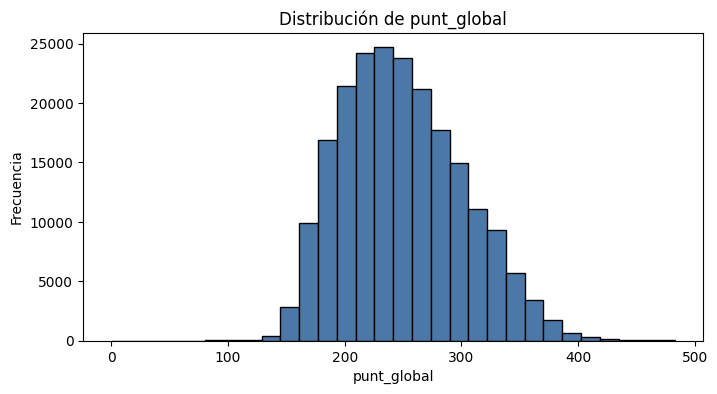


Top 15 correlaciones absolutas con punt_global:
punt_c_naturales                                      0.916240
punt_sociales_ciudadanas                              0.912337
punt_matematicas                                      0.900762
punt_lectura_critica                                  0.895256
punt_ingles                                           0.802447
cole_jornada_completa                                 0.349158
fami_estratovivienda                                  0.285604
cole_jornada_noche                                   -0.279505
fami_educacionmadre_educacion profesional completa    0.250217
fami_tieneautomovil_si                                0.246041
fami_educacionpadre_educacion profesional completa    0.238484
cole_calendario_b                                     0.227701
cole_calendario_a                                    -0.227403
fami_tieneautomovil_no                               -0.212338
cole_naturaleza_no oficial                            0.207747
Name: 

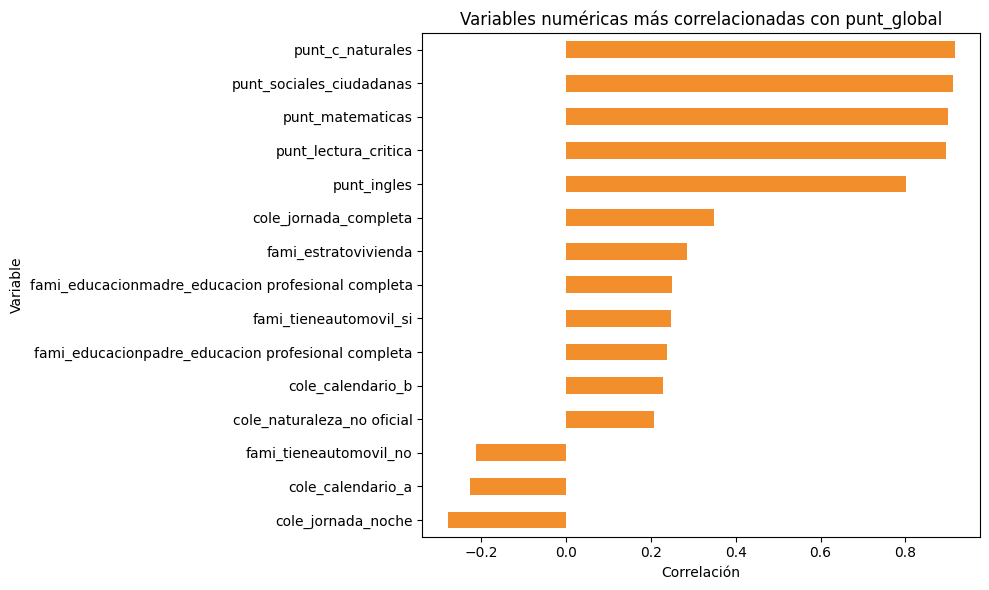

In [11]:
# Revisión general de la base
print("Dimensiones del dataset:", df.shape)
print("Número de columnas:", df.shape[1])
print("Número de filas duplicadas:", df.duplicated().sum())

# Completitud
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print("\nCompletitud:")
if len(missing_values) > 0:
    completeness = pd.DataFrame({
        "faltantes": missing_values,
        "porcentaje": missing_pct
    })
    print(completeness.head(20))
else:
    print("No se encontraron valores faltantes.")

# Tipos de datos
print("\nResumen de tipos de datos:")
print(df.dtypes.value_counts())

# Validez de la variable objetivo
if "punt_global" in df.columns:
    print("\nValidez de punt_global:")
    print(df["punt_global"].describe())
    print("Valores fuera del rango esperado (0 a 500):", ((df["punt_global"] < 0) | (df["punt_global"] > 500)).sum())

    plt.figure(figsize=(8, 4))
    plt.hist(df["punt_global"].dropna(), bins=30, color="#4C78A8", edgecolor="black")
    plt.title("Distribución de punt_global")
    plt.xlabel("punt_global")
    plt.ylabel("Frecuencia")
    plt.show()

# Correlación con variables numéricas
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
if "punt_global" in numeric_cols and len(numeric_cols) > 1:
    corr = df[numeric_cols].corr(numeric_only=True)["punt_global"].drop("punt_global", errors="ignore")
    corr = corr.sort_values(key=lambda s: s.abs(), ascending=False)

    print("\nTop 15 correlaciones absolutas con punt_global:")
    print(corr.head(15))

    plt.figure(figsize=(10, 6))
    corr.head(15).sort_values().plot(kind="barh", color="#F28E2B")
    plt.title("Variables numéricas más correlacionadas con punt_global")
    plt.xlabel("Correlación")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()


En conjunto, esta exploración muestra que la base tiene una estructura consistente para modelado: no se encontraron valores faltantes, la variable `punt_global` se mantiene dentro de un rango válido y los problemas más visibles están en los registros duplicados, que deben interpretarse con cuidado según el propósito del análisis. En la parte de correlación, destacan de forma esperada los puntajes por área como las variables más asociadas con `punt_global`, y también aparecen relaciones relevantes en variables familiares como acceso a internet, computador y nivel educativo de los padres. Esto sugiere que la información disponible sí contiene señal útil para predecir el desempeño global y justifica continuar con la construcción del modelo.


## 4. Definir variable objetivo

Se define como **alto desempeño** obtener un puntaje global mayor o igual a 300.

- `1`: alto desempeño  
- `0`: no alto desempeño


In [12]:
score_col = "punt_global"

if score_col not in df.columns:
    raise ValueError("No se encontró la columna 'punt_global'. Revisa el nombre de la columna en tu archivo.")

df[score_col] = pd.to_numeric(df[score_col], errors="coerce")
df = df.dropna(subset=[score_col])

df["alto_desempeno"] = (df[score_col] >= 300).astype(int)

print("Distribución de la variable objetivo:")
print(df["alto_desempeno"].value_counts())
print("\nDistribución porcentual:")
print(df["alto_desempeno"].value_counts(normalize=True))


Distribución de la variable objetivo:
alto_desempeno
0    172989
1     37706
Name: count, dtype: int64

Distribución porcentual:
alto_desempeno
0    0.82104
1    0.17896
Name: proportion, dtype: float64


## 5. Selección de variables familiares

El modelo solo usará variables familiares:

- Estrato de vivienda
- Educación de la madre
- Educación del padre
- Personas en el hogar
- Cuartos del hogar
- Automóvil
- Lavadora

El código funciona en dos casos:

1. Si el archivo todavía tiene las columnas originales, hace limpieza y One-Hot Encoding.
2. Si el archivo ya tiene las columnas codificadas, las detecta automáticamente.


In [13]:
variables_familiares = [
    'fami_estratovivienda',
    'fami_educacionmadre',
    'fami_educacionpadre',
    'fami_personashogar',
    'fami_cuartoshogar',
    'fami_tieneautomovil',
    'fami_tienelavadora'
]

variables_originales_existentes = [
    col for col in variables_familiares
    if col in df.columns
]

print("Variables familiares originales encontradas:")
print(variables_originales_existentes)


Variables familiares originales encontradas:
['fami_estratovivienda', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_personashogar', 'fami_cuartoshogar', 'fami_tieneautomovil', 'fami_tienelavadora']


## 6. Limpieza y One-Hot Encoding de variables familiares

Esta celda solo aplica el One-Hot Encoding si las variables originales todavía existen.  
Si ya estaban codificadas en el archivo limpio, no repite el proceso.


In [14]:
import re
import unicodedata
import pandas as pd
import numpy as np


def quitar_tildes(texto):
    texto = unicodedata.normalize("NFKD", str(texto))
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    return texto


def texto_base(valor):
    if pd.isna(valor):
        return "sin_informacion"

    texto = quitar_tildes(valor).lower().strip()
    texto = texto.replace("mã¡s", "mas").replace("mã", "mas")
    texto = re.sub(r"\s+", " ", texto)

    if texto in {"", " ", "nan", "none", "null", "n/a", "na", "no reporta", "no registra"}:
        return "sin_informacion"

    if "sin informacion" in texto or "sin_informacion" in texto:
        return "sin_informacion"

    return texto


def normalizar_si_no(valor):
    texto = texto_base(valor)

    if texto in {"si", "s", "sí", "1", "true"}:
        return "si"

    if texto in {"no", "n", "0", "false"}:
        return "no"

    return "sin_informacion"


def normalizar_estrato(valor):
    texto = texto_base(valor)

    if texto == "sin_informacion":
        return texto

    m = re.search(r"([1-6])", texto)
    if m:
        return f"estrato {m.group(1)}"

    return "sin_informacion"


def normalizar_personas_hogar(valor):
    texto = texto_base(valor)

    if texto == "sin_informacion":
        return texto

    mapa = {
        "una": "1", "uno": "1", "dos": "2", "tres": "3", "cuatro": "4",
        "cinco": "5", "seis": "6", "siete": "7", "ocho": "8",
        "nueve": "9", "diez": "10", "once": "11", "doce": "12"
    }

    for palabra, numero in mapa.items():
        texto = re.sub(rf"\b{palabra}\b", numero, texto)

    m = re.search(r"(\d{1,2})", texto)
    if not m:
        return "sin_informacion"

    n = int(m.group(1))

    if n <= 2:
        return "1 a 2"
    elif n <= 4:
        return "3 a 4"
    elif n <= 6:
        return "5 a 6"
    elif n <= 8:
        return "7 a 8"
    else:
        return "9 o mas"


def normalizar_cuartos_hogar(valor):
    texto = texto_base(valor)

    if texto == "sin_informacion":
        return texto

    mapa = {
        "uno": "1", "una": "1",
        "dos": "2",
        "tres": "3",
        "cuatro": "4",
        "cinco": "5",
        "seis": "6",
        "siete": "7",
        "ocho": "8",
        "nueve": "9",
        "diez": "10"
    }

    for palabra, numero in mapa.items():
        texto = re.sub(rf"\b{palabra}\b", numero, texto)

    m = re.search(r"(\d{1,2})", texto)
    if not m:
        return "sin_informacion"

    n = int(m.group(1))

    if n == 1:
        return "uno"
    elif n == 2:
        return "dos"
    elif n == 3:
        return "tres"
    elif n == 4:
        return "cuatro"
    else:
        return "cinco_o_mas"


def normalizar_educacion(valor):
    texto = texto_base(valor)

    if texto == "sin_informacion":
        return texto

    texto = texto.replace("_", " ")
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto


# Aplicar limpieza SOLO a variables familiares
if "fami_estratovivienda" in df.columns:
    df["fami_estratovivienda"] = df["fami_estratovivienda"].apply(normalizar_estrato).astype("category")

if "fami_educacionmadre" in df.columns:
    df["fami_educacionmadre"] = df["fami_educacionmadre"].apply(normalizar_educacion).astype("category")

if "fami_educacionpadre" in df.columns:
    df["fami_educacionpadre"] = df["fami_educacionpadre"].apply(normalizar_educacion).astype("category")

if "fami_personashogar" in df.columns:
    df["fami_personashogar"] = df["fami_personashogar"].apply(normalizar_personas_hogar).astype("category")

if "fami_cuartoshogar" in df.columns:
    df["fami_cuartoshogar"] = df["fami_cuartoshogar"].apply(normalizar_cuartos_hogar).astype("category")

if "fami_tieneautomovil" in df.columns:
    df["fami_tieneautomovil"] = df["fami_tieneautomovil"].apply(normalizar_si_no).astype("category")

if "fami_tienelavadora" in df.columns:
    df["fami_tienelavadora"] = df["fami_tienelavadora"].apply(normalizar_si_no).astype("category")

print("Limpieza familiar finalizada.")

# One-Hot Encoding SOLO de variables familiares
variables_familiares_existentes = [
    col for col in variables_familiares
    if col in df.columns
]

if len(variables_familiares_existentes) == 0:
    raise ValueError("No se encontraron variables familiares para codificar.")

df_fami_dummies = pd.get_dummies(
    df[variables_familiares_existentes],
    columns=variables_familiares_existentes,
    prefix=variables_familiares_existentes,
    drop_first=False,
    dummy_na=False,
).astype(int)

columnas_familiares_encoded = df_fami_dummies.columns.tolist()

# Reemplazar las columnas originales por las dummies en el dataframe final del modelo
df = df.drop(columns=variables_familiares_existentes, errors="ignore")
df = pd.concat([df, df_fami_dummies], axis=1)

print("Número de columnas familiares codificadas:", len(columnas_familiares_encoded))
print(columnas_familiares_encoded[:20])

Limpieza familiar finalizada.
Número de columnas familiares codificadas: 46
['fami_estratovivienda_estrato 1', 'fami_estratovivienda_estrato 2', 'fami_estratovivienda_estrato 3', 'fami_estratovivienda_estrato 4', 'fami_estratovivienda_estrato 5', 'fami_estratovivienda_estrato 6', 'fami_estratovivienda_sin_informacion', 'fami_educacionmadre_educacion profesional completa', 'fami_educacionmadre_educacion profesional incompleta', 'fami_educacionmadre_ninguno', 'fami_educacionmadre_postgrado', 'fami_educacionmadre_primaria completa', 'fami_educacionmadre_primaria incompleta', 'fami_educacionmadre_secundaria (bachillerato) completa', 'fami_educacionmadre_secundaria (bachillerato) incompleta', 'fami_educacionmadre_sin_informacion', 'fami_educacionmadre_tecnica o tecnologica completa', 'fami_educacionmadre_tecnica o tecnologica incompleta', 'fami_educacionpadre_educacion profesional completa', 'fami_educacionpadre_educacion profesional incompleta']


## 7. Construir matriz de variables predictoras

Se usa únicamente el conjunto de columnas familiares codificadas.


In [15]:
X = df[columnas_familiares_encoded].copy()
y = df["alto_desempeno"].copy()

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

X.head()


Dimensiones de X: (210695, 92)
Dimensiones de y: (210695,)


,fami_estratovivienda_estrato 1,fami_estratovivienda_estrato 1,fami_estratovivienda_estrato 2,fami_estratovivienda_estrato 2,fami_estratovivienda_estrato 3,fami_estratovivienda_estrato 3,fami_estratovivienda_estrato 4,fami_estratovivienda_estrato 4,fami_estratovivienda_estrato 5,fami_estratovivienda_estrato 5,fami_estratovivienda_estrato 6,fami_estratovivienda_estrato 6,fami_estratovivienda_sin_informacion,fami_estratovivienda_sin_informacion,fami_educacionmadre_educacion profesional completa,fami_educacionmadre_educacion profesional completa,fami_educacionmadre_educacion profesional incompleta,fami_educacionmadre_educacion profesional incompleta,fami_educacionmadre_ninguno,fami_educacionmadre_ninguno,fami_educacionmadre_postgrado,fami_educacionmadre_postgrado,fami_educacionmadre_primaria completa,fami_educacionmadre_primaria completa,fami_educacionmadre_primaria incompleta,fami_educacionmadre_primaria incompleta,fami_educacionmadre_secundaria (bachillerato) completa,fami_educacionmadre_secundaria (bachillerato) completa,fami_educacionmadre_secundaria (bachillerato) incompleta,fami_educacionmadre_secundaria (bachillerato) incompleta,fami_educacionmadre_sin_informacion,fami_educacionmadre_sin_informacion,fami_educacionmadre_tecnica o tecnologica completa,fami_educacionmadre_tecnica o tecnologica completa,fami_educacionmadre_tecnica o tecnologica incompleta,fami_educacionmadre_tecnica o tecnologica incompleta,fami_educacionpadre_educacion profesional completa,fami_educacionpadre_educacion profesional completa,fami_educacionpadre_educacion profesional incompleta,fami_educacionpadre_educacion profesional incompleta,fami_educacionpadre_ninguno,fami_educacionpadre_ninguno,fami_educacionpadre_postgrado,fami_educacionpadre_postgrado,fami_educacionpadre_primaria completa,fami_educacionpadre_primaria completa,fami_educacionpadre_primaria incompleta,fami_educacionpadre_primaria incompleta,fami_educacionpadre_secundaria (bachillerato) completa,fami_educacionpadre_secundaria (bachillerato) completa,fami_educacionpadre_secundaria (bachillerato) incompleta,fami_educacionpadre_secundaria (bachillerato) incompleta,fami_educacionpadre_sin_informacion,fami_educacionpadre_sin_informacion,fami_educacionpadre_tecnica o tecnologica completa,fami_educacionpadre_tecnica o tecnologica completa,fami_educacionpadre_tecnica o tecnologica incompleta,fami_educacionpadre_tecnica o tecnologica incompleta,fami_personashogar_1 a 2,fami_personashogar_1 a 2,fami_personashogar_3 a 4,fami_personashogar_3 a 4,fami_personashogar_5 a 6,fami_personashogar_5 a 6,fami_personashogar_7 a 8,fami_personashogar_7 a 8,fami_personashogar_9 o mas,fami_personashogar_9 o mas,fami_personashogar_sin_informacion,fami_personashogar_sin_informacion,fami_cuartoshogar_cuatro,fami_cuartoshogar_cuatro,fami_cuartoshogar_dos,fami_cuartoshogar_dos,fami_cuartoshogar_sin_informacion,fami_cuartoshogar_sin_informacion,fami_cuartoshogar_tres,fami_cuartoshogar_tres,fami_cuartoshogar_uno,fami_cuartoshogar_uno,fami_tieneautomovil_no,fami_tieneautomovil_no,fami_tieneautomovil_si,fami_tieneautomovil_si,fami_tieneautomovil_sin_informacion,fami_tieneautomovil_sin_informacion,fami_tienelavadora_no,fami_tienelavadora_no,fami_tienelavadora_si,fami_tienelavadora_si,fami_tienelavadora_sin_informacion,fami_tienelavadora_sin_informacion
0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0
1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0
2,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0
3,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,1,0,0

## 8. División entrenamiento / prueba

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True))


Train: (168556, 92)
Test: (42139, 92)

Distribución en entrenamiento:
alto_desempeno
0    0.821039
1    0.178961
Name: proportion, dtype: float64


## 9. Modelo base: Regresión logística

Este modelo sirve como línea base para comparar el desempeño de la red neuronal.


In [17]:
baseline = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)
y_proba_base = baseline.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_base),
    "precision": precision_score(y_test, y_pred_base, zero_division=0),
    "recall": recall_score(y_test, y_pred_base, zero_division=0),
    "f1": f1_score(y_test, y_pred_base, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_base)
}

baseline_metrics


{'accuracy': 0.837703789838392,
 'precision': 0.6660359508041628,
 'recall': 0.18671263758122264,
 'f1': 0.29166235111341277,
 'roc_auc': 0.7637514703807099}

## 10. Red neuronal

Se propone una red neuronal sencilla para clasificación binaria.


In [18]:
def construir_modelo(input_dim, capa_1=64, capa_2=32, dropout_1=0.30, dropout_2=0.20, learning_rate=0.001):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(capa_1, activation="relu"),
        layers.Dropout(dropout_1),
        layers.Dense(capa_2, activation="relu"),
        layers.Dropout(dropout_2),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )

    return model

model = construir_modelo(input_dim=X_train.shape[1])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         5,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,065 (31.50 KB)

 Trainable params: 8,065 (31.50 KB)

 Non-trainable params: 0 (0.00 B)

## 11. Entrenamiento del modelo

In [19]:
params = {
    "capa_1": 64,
    "capa_2": 32,
    "dropout_1": 0.30,
    "dropout_2": 0.20,
    "learning_rate": 0.001,
    "epochs": 30,
    "batch_size": 128,
    "class_weight_1": 1.5
}

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train
)

class_weight = {
    0: 1.0,
    1: params["class_weight_1"]
}

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_fit,
    y_fit,
    validation_data=(X_val, y_val),
    epochs=params["epochs"],
    batch_size=params["batch_size"],
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8297 - auc: 0.7476 - loss: 0.5239 - val_accuracy: 0.8334 - val_auc: 0.7674 - val_loss: 0.4074
Epoch 2/30
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8325 - auc: 0.7624 - loss: 0.5129 - val_accuracy: 0.8345 - val_auc: 0.7686 - val_loss: 0.4064
Epoch 3/30
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8333 - auc: 0.7647 - loss: 0.5110 - val_accuracy: 0.8345 - val_auc: 0.7696 - val_loss: 0.4057
Epoch 4/30
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8337 - auc: 0.7663 - loss: 0.5098 - val_accuracy: 0.8353 - val_auc: 0.7698 - val_loss: 0.4053
Epoch 5/30
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8341 - auc: 0.7675 - loss: 0.5086 - val_accuracy: 0.8355 - val_auc: 0.7700 - val_loss: 0.4036
Epoch 6/30
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8332 - auc: 0.7687 - loss: 0.5079 - val_accuracy: 0.8357 - val_auc: 0.7699 - val_loss: 0.4042
Epoch 7/30
1054/1054 ━━━━━━━

## 12. Evaluación del modelo

In [20]:
y_proba_nn = model.predict(X_test).ravel()
y_pred_nn = (y_proba_nn >= 0.5).astype(int)

nn_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_nn),
    "precision": precision_score(y_test, y_pred_nn, zero_division=0),
    "recall": recall_score(y_test, y_pred_nn, zero_division=0),
    "f1": f1_score(y_test, y_pred_nn, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_nn)
}

nn_metrics


1317/1317 ━━━━━━━━━━━━━━━━━━━━ 1s 713us/step


{'accuracy': 0.835615463110183,
 'precision': 0.5784363822176801,
 'recall': 0.3002254342925341,
 'f1': 0.3952859013531209,
 'roc_auc': 0.7677917570279753}

## 13. Comparación de modelos

In [21]:
comparison = pd.DataFrame([
    {"modelo": "Regresión logística", **baseline_metrics},
    {"modelo": "Red neuronal", **nn_metrics}
])

comparison


,modelo,accuracy,precision,recall,f1,roc_auc
0,Regresión logística,0.837704,0.666036,0.186713,0.291662,0.763751
1,Red neuronal,0.835615,0.578436,0.300225,0.395286,0.767792


## 14. Matriz de confusión

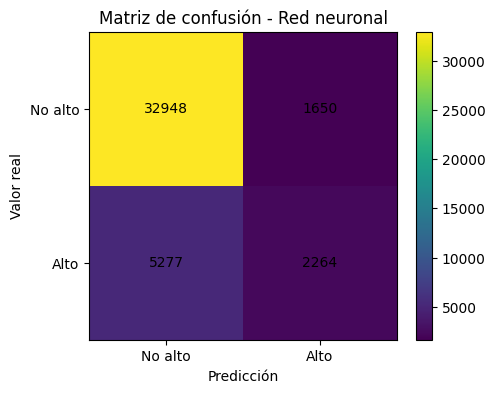

                   precision    recall  f1-score   support

No alto desempeño       0.86      0.95      0.90     34598
   Alto desempeño       0.58      0.30      0.40      7541

         accuracy                           0.84     42139
        macro avg       0.72      0.63      0.65     42139
     weighted avg       0.81      0.84      0.81     42139



In [22]:
cm = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Matriz de confusión - Red neuronal")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks([0, 1], ["No alto", "Alto"])
plt.yticks([0, 1], ["No alto", "Alto"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

print(classification_report(y_test, y_pred_nn, target_names=["No alto desempeño", "Alto desempeño"]))


## 15. Curva ROC

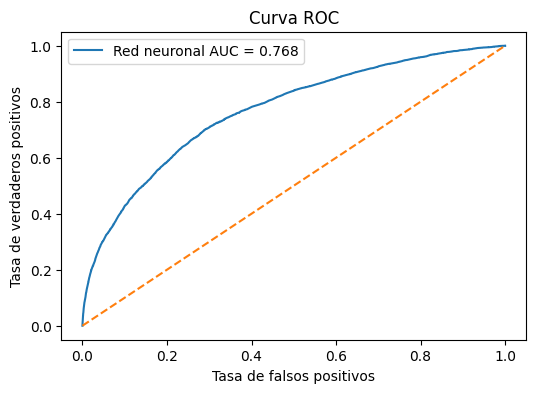

In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_nn)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"Red neuronal AUC = {nn_metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC")
plt.legend()
plt.show()


## 16. Registro de experimento con MLflow

Si MLflow está instalado, se registran parámetros, métricas y modelo.


In [ ]:
if MLFLOW_AVAILABLE:
    try:
        # Levantar MLflow antes de ejecutar esta celda:
        # mlflow server --backend-store-uri sqlite:///mlflow.db --default-artifact-root ./mlruns --host 127.0.0.1 --port 5000
        mlflow.set_tracking_uri("http://localhost:5000")
        experiment = mlflow.set_experiment("Saber11_Atlantico_Clasificacion")

        X_train_np = X_train.to_numpy()
        X_test_np = X_test.to_numpy()

        tf.keras.utils.set_random_seed(RANDOM_STATE)

        with mlflow.start_run(
            experiment_id=experiment.experiment_id,
            run_name="modelo_red_neuronal_sofia"
        ):
            mlflow.keras.autolog()

            mlflow.log_params(params)
            mlflow.log_param("numero_variables_encoded", X_train.shape[1])
            mlflow.log_param("patience", early_stop.patience)
            mlflow.log_param("tracking_uri", "http://localhost:5000")

            for metric_name, metric_value in nn_metrics.items():
                mlflow.log_metric(metric_name, metric_value)

            for epoch_index in range(len(history.history.get("loss", []))):
                mlflow.log_metric("loss", history.history["loss"][epoch_index], step=epoch_index)

                if "accuracy" in history.history:
                    mlflow.log_metric("accuracy", history.history["accuracy"][epoch_index], step=epoch_index)
                if "auc" in history.history:
                    mlflow.log_metric("auc", history.history["auc"][epoch_index], step=epoch_index)
                if "val_loss" in history.history:
                    mlflow.log_metric("val_loss", history.history["val_loss"][epoch_index], step=epoch_index)
                if "val_accuracy" in history.history:
                    mlflow.log_metric("val_accuracy", history.history["val_accuracy"][epoch_index], step=epoch_index)
                if "val_auc" in history.history:
                    mlflow.log_metric("val_auc", history.history["val_auc"][epoch_index], step=epoch_index)

            mlflow.log_metric("final_loss", history.history["loss"][-1])
            if "val_loss" in history.history:
                mlflow.log_metric("final_val_loss", history.history["val_loss"][-1])
            if "accuracy" in history.history:
                mlflow.log_metric("final_accuracy", history.history["accuracy"][-1])
            if "auc" in history.history:
                mlflow.log_metric("final_auc", history.history["auc"][-1])
            if "val_accuracy" in history.history:
                mlflow.log_metric("final_val_accuracy", history.history["val_accuracy"][-1])
            if "val_auc" in history.history:
                mlflow.log_metric("final_val_auc", history.history["val_auc"][-1])

            mlflow.keras.log_model(model, "keras-model")

        print("Experimento registrado en MLflow usando http://localhost:5000.")
    except Exception as error:
        raise RuntimeError(
            "MLflow debe estar levantado en localhost:5000 para registrar el experimento. "
            "Ejecuta primero: mlflow server --backend-store-uri sqlite:///mlflow.db --default-artifact-root ./mlruns --host 127.0.0.1 --port 5000"
        ) from error
else:
    print("MLflow no está disponible en este ambiente.")

2026/05/22 19:42:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/22 19:42:56 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


🏃 View run modelo_red_neuronal_sofia at: http://localhost:5000/#/experiments/1/runs/4ce06080bf584d92ac0bdf1220340d7c
🧪 View experiment at: http://localhost:5000/#/experiments/1
Experimento registrado en MLflow usando http://localhost:5000.
